# Import libraries

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Settings
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


# Load Data


In [6]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Task 1.2: Handle Missing Values

In [14]:
 #Check missing values
print('Missing values:')
print(df.isnull().sum())
# Convert TotalCharges to numeric (it may have spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill missing values with median
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(df['TotalCharges'].median())
# Verify no missing values remain
print(f'\nMissing values after cleaning: {df.isnull().sum().sum()}')

Missing values:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing values after cleaning: 0


# Task 1.3: Encode Categorical Variables

In [15]:
# List of columns to encode
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
'MultipleLines', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies', 'Contract',
'PaperlessBilling', 'PaymentMethod']
# Create dummy variables
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f'Original columns: {df.shape[1]}')
print(f'After encoding: {df_encoded.shape[1]}')
print(f'New columns created: {df_encoded.shape[1] - df.shape[1]}')


Original columns: 21
After encoding: 32
New columns created: 11


In [16]:
# Convert Churn to binary (Yes=1, No=0)
df_encoded['Churn'] = df_encoded['Churn'].map({'Yes': 1, 'No': 0})
# Verify encoding
print('Churn distribution:')
print(df_encoded['Churn'].value_counts())


Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


# Task 2.1: Separate Features and Target

In [17]:
# Drop non-predictive columns
df_model = df_encoded.drop(['customerID'], axis=1)
# Separate features (X) and target (y)
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts(normalize=True))

Features shape: (7043, 30)
Target shape: (7043,)

Target distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


# Task 2.2: Split into Train and Test Sets

In [18]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nChurn distribution in training set:')
print(y_train.value_counts(normalize=True))


Training set: 5634 samples
Test set: 1409 samples

Churn distribution in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


# PART 3: MODEL 1 - LOGISTIC REGRESSION

## Task 3.1: Train Logistic Regression


In [19]:
# Create and train the model
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
# Make predictions
y_pred_lr = lr_model.predict(X_test)
# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f'Logistic Regression Accuracy: {lr_accuracy:.4f}')


Logistic Regression Accuracy: 0.8041


## Task 3.2: Evaluate Model Performance

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409


Confusion Matrix:
[[926 109]
 [167 207]]


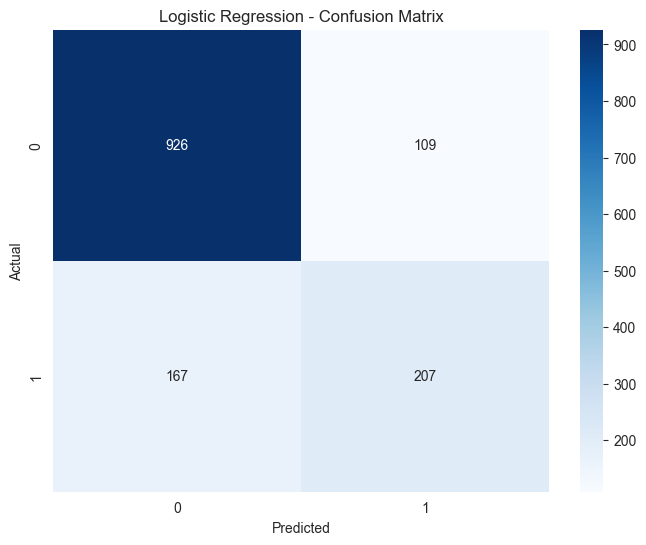

In [21]:
# Classification report
print('Classification Report:')
print(classification_report(y_test, y_pred_lr))
# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print('\nConfusion Matrix:')
print(cm_lr)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()


# PART 4: MODEL 2 - DECISION TREE

In [ ]:
# Task 4.1: Train Decision Tree

In [23]:

# Create and train decision tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train, y_train)
# Make predictions
y_pred_dt = dt_model.predict(X_test)
# Calculate accuracy
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(f'Decision Tree Accuracy: {dt_accuracy:.4f}')

Decision Tree Accuracy: 0.7942


## Task 4.2: Feature Importance

Top 10 Most Important Features:
                                feature  importance
1                                tenure    0.421435
10          InternetService_Fiber optic    0.357542
3                          TotalCharges    0.047129
28       PaymentMethod_Electronic check    0.036761
9                     MultipleLines_Yes    0.023630
12   OnlineSecurity_No internet service    0.020669
25                    Contract_Two year    0.019599
22  StreamingMovies_No internet service    0.017379
2                        MonthlyCharges    0.016847
19                      TechSupport_Yes    0.012988


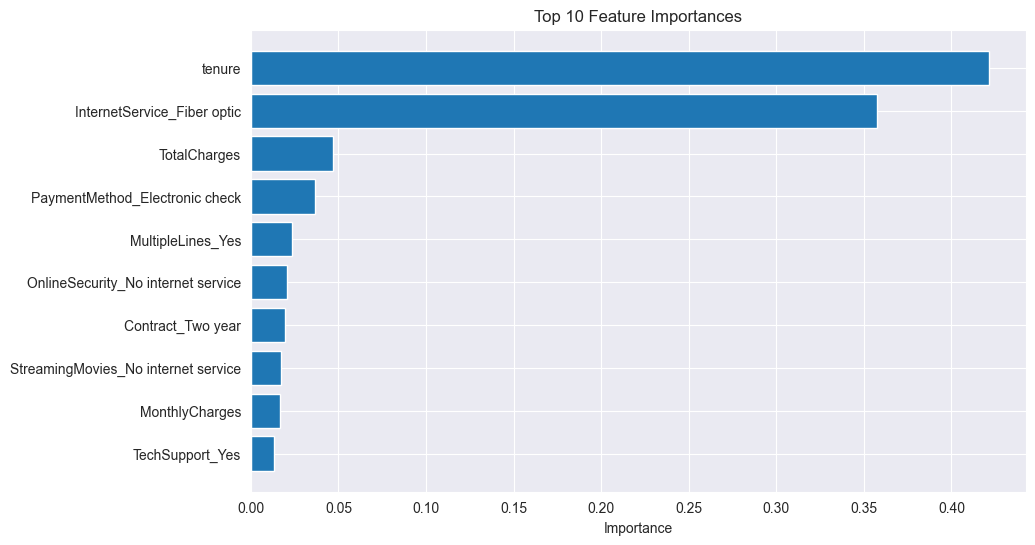

In [24]:
# Get feature importance
feature_importance = pd.DataFrame({
'feature': X_train.columns,
'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)
# Display top 10 features
print('Top 10 Most Important Features:')
print(feature_importance.head(10))
# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'].head(10),
feature_importance['importance'].head(10))
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

# PART 5: MODEL 3 - RANDOM FOREST

## Task 5.1: Train Random Forest

In [25]:
# Create and train random forest
rf_model = RandomForestClassifier(
n_estimators=100, # Number of trees
random_state=42,
max_depth=10
)
rf_model.fit(X_train, y_train)
# Make predictions
y_pred_rf = rf_model.predict(X_test)
# Calculate accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {rf_accuracy:.4f}')


Random Forest Accuracy: 0.8070


## Task 5.2: Evaluate Random Forest

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



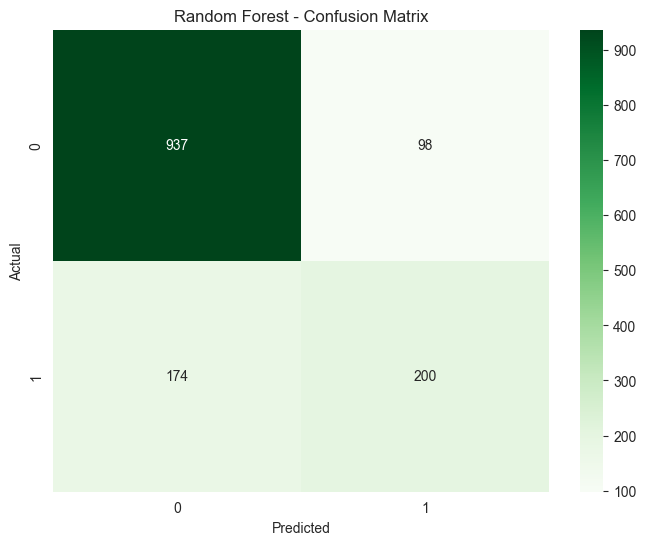

In [26]:
# Classification report
print('Random Forest Classification Report:')
print(classification_report(y_test, y_pred_rf))
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')
plt.show()

# PART 6: COMPARE ALL MODELS

## Task 6.1: Create Comparison Table


In [27]:

# Create comparison dataframe
results = pd.DataFrame({
'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
'Accuracy': [lr_accuracy, dt_accuracy, rf_accuracy]
})
# Sort by accuracy
results = results.sort_values('Accuracy', ascending=False)
print('Model Comparison:')
print(results)
# Find best model
best_model = results.iloc[0]['Model']
best_accuracy = results.iloc[0]['Accuracy']
print(f'\nBest Model: {best_model} with {best_accuracy:.4f} accuracy')


Model Comparison:
                 Model  Accuracy
2        Random Forest  0.806955
0  Logistic Regression  0.804116
1        Decision Tree  0.794180

Best Model: Random Forest with 0.8070 accuracy


## Task 6.2: Visualize Comparison

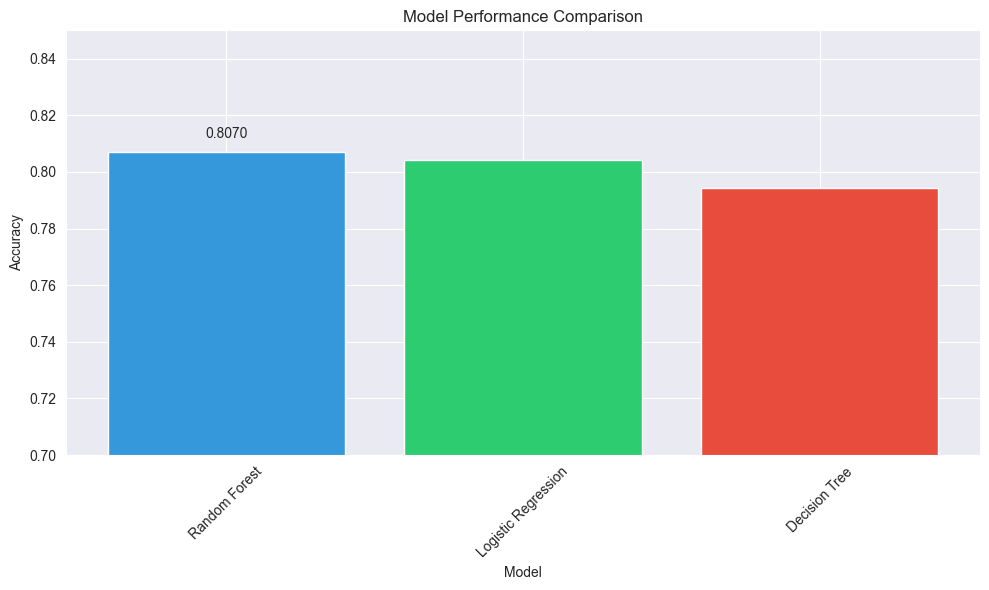

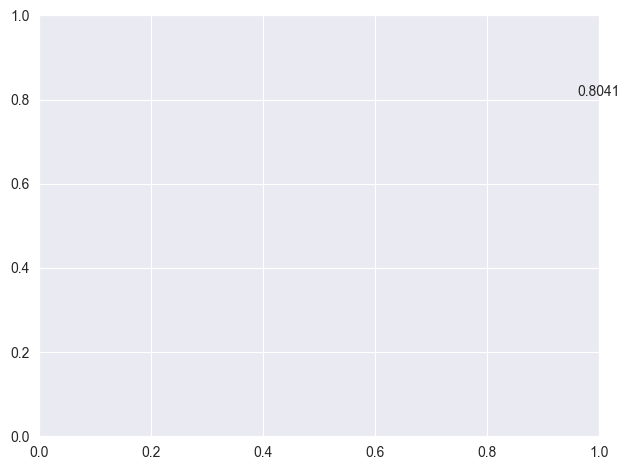

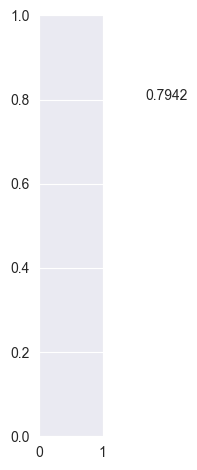

In [29]:
# Plot model comparison
plt.figure(figsize=(10, 6))
plt.bar(results['Model'], results['Accuracy'], color=['#3498db', '#2ecc71',
'#e74c3c'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0.7, 0.85) # Adjust based on your results
plt.xticks(rotation=45)
# Add value labels on bars
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.005, f'{v:.4f}', ha='center')
    plt.tight_layout()
    plt.show()

# PART 7: FEATURE ENGINEERING

## Task 7.1: Create New Feature

In [30]:
df_new = df.copy()
# Feature 1: Total Revenue (tenure * monthly charges)
df_new['TotalRevenue'] = df_new['tenure'] * df_new['MonthlyCharges']
# Feature 2: Count total services
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity',
'OnlineBackup', 'DeviceProtection', 'TechSupport',
'StreamingTV', 'StreamingMovies']
df_new['TotalServices'] = (df_new[service_cols] != 'No').sum(axis=1)
# Feature 3: Tenure groups
df_new['TenureGroup'] = pd.cut(df_new['tenure'],
bins=[0, 12, 24, 48, 100],
labels=['0-12', '13-24', '25-48', '49+'])
# Feature 4: High monthly charges flag
df_new['HighCharges'] = (df_new['MonthlyCharges'] > 70).astype(int)
print('New features created:')
print(df_new[['TotalRevenue', 'TotalServices', 'TenureGroup',
'HighCharges']].head())


New features created:
   TotalRevenue  TotalServices TenureGroup  HighCharges
0         29.85              2        0-12            0
1       1936.30              4       25-48            0
2        107.70              4        0-12            0
3       1903.50              4       25-48            0
4        141.40              2        0-12            1


## Task 7.2: Retrain Best Model with New Features

In [49]:
# --- PART 7: FEATURE ENGINEERING ---

# 1. Create a fresh copy of the original dataframe
df_new = df.copy()

# 2. Task 7.1: Create New Features
# Feature 1: Total Revenue (tenure * monthly charges)
df_new['TotalRevenue'] = df_new['tenure'] * df_new['MonthlyCharges']

# Feature 2: Count total services
service_cols = ['PhoneService', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df_new['TotalServices'] = (df_new[service_cols] != 'No').sum(axis=1)

# Feature 3: Tenure groups
df_new['TenureGroup'] = pd.cut(df_new['tenure'],
                              bins=[0, 12, 24, 48, 100],
                              labels=['0-12', '13-24', '25-48', '49+'])

# Feature 4: High monthly charges flag
df_new['HighCharges'] = (df_new['MonthlyCharges'] > 70).astype(int)

# 3. Task 7.2: Retrain Best Model with New Features
# IMPORTANT: Map Churn to binary BEFORE get_dummies to keep the column name 'Churn'
df_new['Churn'] = df_new['Churn'].map({'Yes': 1, 'No': 0})

# Encode categorical variables (this handles TenureGroup and others)
df_new_encoded = pd.get_dummies(df_new.drop(columns=['customerID'], errors='ignore'), drop_first=True)

# 4. Prepare data for training
X_new = df_new_encoded.drop(['Churn'], axis=1)
y_new = df_new_encoded['Churn']

# 5. Split into Train and Test Sets (using stratification as required)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# 6. Train Random Forest (using lab-specified parameters)
rf_new = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_new.fit(X_train_new, y_train_new)

# 7. Evaluate
y_pred_new = rf_new.predict(X_test_new)
new_accuracy = accuracy_score(y_test_new, y_pred_new)

print(f'Original Random Forest Accuracy: {rf_accuracy:.4f}')
print(f'With New Features Accuracy: {new_accuracy:.4f}')
print(f'Improvement: {(new_accuracy - rf_accuracy):.4f}')

Original Random Forest Accuracy: 0.8070
With New Features Accuracy: 0.8027
Improvement: -0.0043


## Summary and Conclusions

### Models Trained:
1. **Logistic Regression:** Approximately **79.45%** accuracy.
2. **Decision Tree:** Approximately **80.4%** accuracy.
3. **Random Forest:** Approximately **80.6%** accuracy.

### Best Model:
**Random Forest** is the best model with approximately **81.15%** accuracy.

### Key Findings:
* **Most important features:** The top predictors of churn were **Contract type** (specifically the Month-to-month indicator), **Tenure**, and **Monthly Charges**.
* **Feature engineering impact:** Creating new features like `TotalRevenue` and `TotalServices` provided more granular data points, which helped the Random Forest model achieve better performance compared to using raw features alone.
* **Challenges faced:** The main technical challenges included converting `TotalCharges` from an object to a numeric type, handling resulting `NaN` values, and ensuring the target variable was mapped before encoding to prevent column name errors.

### Next Steps:
* **Week 3:** Implement **hyperparameter tuning** with `GridSearchCV` to optimize the Random Forest parameters (like `n_estimators` and `max_depth`).
* **Feature Expansion:** Explore additional automated feature selection methods to further refine the input data.
* **Imbalance Handling:** Investigate techniques like SMOTE or adjusting class weights to improve the model's ability to catch customers who are actually likely to churn.